In [106]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from tqdm import tqdm
import json
from catboost import CatBoostRegressor


import warnings

warnings.filterwarnings("ignore")

In [2]:
taxi_path = 'Data/NAB/data/realKnownCause/nyc_taxi.csv'
ambient_path = 'Data/NAB/data/realKnownCause/ambient_temperature_system_failure.csv'
cpu_path = 'Data/NAB/data/realKnownCause/cpu_utilization_asg_misconfiguration.csv'

In [3]:
taxi_df = pd.read_csv(taxi_path)
ambient_temp_df = pd.read_csv(ambient_path)
cpu_df = pd.read_csv(cpu_path)

In [4]:
#добавим labels
with open('Data/NAB/labels/combined_labels.json') as f:
    labels = json.load(f)

labels['realKnownCause/nyc_taxi.csv'].append(taxi_df['timestamp'].iloc[-1])

taxi_df['anomaly'] = 0

for i in range(0, len(labels['realKnownCause/nyc_taxi.csv']) - 1, 2):
    start = labels['realKnownCause/nyc_taxi.csv'][i]
    end = labels['realKnownCause/nyc_taxi.csv'][i+1]

    mask = ((taxi_df['timestamp'] <= end) & (taxi_df['timestamp'] >= start))
    taxi_df.loc[mask, 'anomaly'] = 1
    

ambient_temp_df['anomaly'] = 0

for i in range(0, len(labels['realKnownCause/ambient_temperature_system_failure.csv']) - 1, 2):
    start = labels['realKnownCause/ambient_temperature_system_failure.csv'][i]
    end = labels['realKnownCause/ambient_temperature_system_failure.csv'][i+1]

    mask = ((ambient_temp_df['timestamp'] <= end) & (ambient_temp_df['timestamp'] >= start))
    ambient_temp_df.loc[mask, 'anomaly'] = 1

cpu_df['anomaly'] = 0

for i in range(0, len(labels['realKnownCause/cpu_utilization_asg_misconfiguration.csv']) - 1, 2):
    start = labels['realKnownCause/cpu_utilization_asg_misconfiguration.csv'][i]
    end = labels['realKnownCause/cpu_utilization_asg_misconfiguration.csv'][i+1]

    mask = ((cpu_df['timestamp'] <= end) & (cpu_df['timestamp'] >= start))
    cpu_df.loc[mask, 'anomaly'] = 1

In [5]:
def train_test_timeseries_split(df, train_size = 0.8):

    df['timestamp'] = pd.to_datetime(df['timestamp'])
    first_date_anomaly = df[df['anomaly'] == 1].iloc[0,0]
    
    train = df[df['timestamp'] < df[df['anomaly'] == 1].iloc[0,0]]
    test = df[df['timestamp'] >= df[df['anomaly'] == 1].iloc[0,0]]

    X_train = train.drop(columns = 'anomaly')
    y_train = train['anomaly']

    X_test = test.drop(columns = 'anomaly')
    y_test = test['anomaly']
    return X_train, y_train, X_test, y_test

## Threshold calibration

### Порог задается вручную

Такая реализация уже была использована для предидущих расчетов

In [6]:
def static_threshold(df:pd.DataFrame, x:float = 2, **kwargs):
    df['threshold'] = float(x)
    df['predicted'] = (df['score'] >= df["threshold"]).astype(int)
    return df

### Порог задается по train квантилю

In [7]:
def rolling_quantile_threshold(
    df:pd.DataFrame,
    window:int,
    quantile:float = 0.99,
    min_periods:int = None,
    fallback_threshold:float = None,
    **kwargs
):
    if min_periods is None:
        min_periods = max(1, window // 2)

    df['threshold'] = (
        df['score']
        .shift(1)
        .rolling(window=window, min_periods=min_periods)
        .quantile(quantile)
    )

    if fallback_threshold is None:
        fallback_threshold = df['score'].quantile(quantile)

    df["threshold"] = df["threshold"].fillna(fallback_threshold)
    df['predicted'] = (df['score'] >= df["threshold"]).astype(int)

    return df

### Context-aware threshold

Context-aware threshold основан на предположении, что распределение anomaly score может различаться в зависимости от временного контекста наблюдения. Например, для рядов с выраженной суточной сезонностью нормальная ошибка модели может отличаться в разные часы суток. Поэтому вместо единого глобального порога рассчитывается набор пороговых значений для разных сезонных позиций или временных групп. Такой подход позволяет учитывать неоднородность временного ряда и снижать количество ложных срабатываний в периодах естественно высокой вариативности.

In [8]:
def context_aware_threshold(
    X_train:pd.DataFrame,
    X_test:pd.DataFrame,
    quantile:float = 0.99,
    context_col:str = 'hour',
    **kwargs
):

    if context_col == "hour":
        X_train["context"] = X_train['timestamp'].dt.hour
        X_test["context"] = X_test['timestamp'].dt.hour

    elif context_col == "dayofweek":
        X_train["context"] = X_train['timestamp'].dt.dayofweek
        X_test["context"] = X_test['timestamp'].dt.dayofweek

    elif context_col == "dayofweek_hour":
        X_train["context"] = (
            X_train['timestamp'].dt.dayofweek.astype(str)
            + "_"
            + X_train['timestamp'].dt.hour.astype(str)
        )

        X_test["context"] = (
            X_test['timestamp'].dt.dayofweek.astype(str)
            + "_"
            + X_test['timestamp'].dt.hour.astype(str)
        )

    else:
        raise ValueError("context_col должен быть 'hour', 'dayofweek' или 'dayofweek_hour'")

    global_threshold = X_train['score'].quantile(quantile)
    
    context_thresholds = (
        X_train
        .groupby("context")['score']
        .quantile(quantile)
    )

    X_train["threshold"] = X_train["context"].map(context_thresholds)
    X_test["threshold"] = X_test["context"].map(context_thresholds)
    
    X_train["threshold"] = X_train["threshold"].fillna(global_threshold)
    X_test["threshold"] = X_test["threshold"].fillna(global_threshold)

    X_train['predicted'] = (X_train['score'] >= X_train["threshold"]).astype(int)
    X_test['predicted'] = (X_test['score'] >= X_test["threshold"]).astype(int)

    return X_train, X_test

### Uncertainty-aware threshold

Uncertainty-aware threshold учитывает не только величину ошибки прогноза, но и неопределённость модели в конкретный момент времени. В данном подходе одна и та же абсолютная ошибка может интерпретироваться по-разному в зависимости от ожидаемой вариативности ряда. Если модель обычно ошибается сильнее в определённом временном контексте, порог для таких точек должен быть выше. В рамках uncertainty-aware threshold дополнительно используется интервал допустимых значений прогноза. Границы интервала рассчитываются на основе прогнозного значения и распределения ошибок прогноза на обучающей выборке. Если фактическое значение выходит за нижнюю или верхнюю границу интервала, наблюдение считается аномальным. Такой подход позволяет выявлять как аномально высокие, так и аномально низкие значения временного ряда.

In [9]:
def prediction_interval_threshold(
    X_train:pd.DataFrame,
    X_test:pd.DataFrame,
    k:float = 3,
    **kwargs
):
    k = float(k)

    mu_error = X_train['error_forecast'].mean()
    std_error = X_train['error_forecast'].std()

    if std_error == 0:
        std_error = 1e-8

    X_train["lower_bound"] = X_train['predicted_m'] + mu_error - k * std_error
    X_train["upper_bound"] = X_train['predicted_m'] + mu_error + k * std_error

    X_test["lower_bound"] = X_test['predicted_m'] + mu_error - k * std_error
    X_test["upper_bound"] = X_test['predicted_m'] + mu_error + k * std_error

    X_train["threshold"] = k
    X_test["threshold"] = k

    X_train["predicted"] = (
        (X_train['value'] < X_train["lower_bound"]) |
        (X_train['value'] > X_train["upper_bound"])
    ).astype(int)

    X_test["predicted"] = (
        (X_test['value'] < X_test["lower_bound"]) |
        (X_test['value'] > X_test["upper_bound"])
    ).astype(int)

    return X_train, X_test

In [10]:
def apply_threshold(
    X_train:pd.DataFrame,
    X_test:pd.DataFrame,
    threshold_name:str = 'static_threshold',
    threshold:float = 2,
    window:int = None,
    quantile:float = 0.99,
    context_col:str = 'hour',
    k:float = 3
):
    if threshold_name == 'static_threshold':
        X_train = static_threshold(X_train, threshold)
        X_test = static_threshold(X_test, threshold)

    elif threshold_name == 'rolling_quantile_threshold':
        if window is None:
            raise ValueError("Для rolling_quantile_threshold нужно передать window")

        X_train = rolling_quantile_threshold(
            X_train,
            window=window,
            quantile=quantile
        )

        train_fallback_threshold = X_train['score'].quantile(quantile)

        X_test = rolling_quantile_threshold(
            X_test,
            window=window,
            quantile=quantile,
            fallback_threshold=train_fallback_threshold
        )

    elif threshold_name == 'context_aware_threshold':
        X_train, X_test = context_aware_threshold(
            X_train,
            X_test,
            quantile=quantile,
            context_col=context_col
        )

    elif threshold_name == 'prediction_interval_thresh':
        X_train, X_test = prediction_interval_threshold(
            X_train,
            X_test,
            k=k
        )

    else:
        raise ValueError("Неизвестный threshold_name")

    return X_train, X_test

In [11]:
def do_plot(df:pd.DataFrame, X_train:pd.DataFrame, X_test:pd.DataFrame, name_df:str):
    fig, axes = plt.subplots(2, 1, figsize=(16, 9))
    plt.suptitle(name_df)
    
    axes[0].set_title('Временной ряд')
    
        
    sns.lineplot(X_train, x = 'timestamp', y = 'value', ax=axes[0], color = 'lightblue')
    sns.lineplot(X_train[X_train['predicted'] == 1], x = 'timestamp', y = 'value', label = 'Модель посчитала выбросом',
                    ax = axes[0], color = 'red')
    sns.lineplot(X_test[X_test['predicted'] == 1], x = 'timestamp', y = 'value', label = 'Модель посчитала выбросом',
                    ax = axes[0], color = 'red')
    sns.lineplot(X_test[X_test['predicted'] == 0], x = 'timestamp', y = 'value', label = 'Модель посчитала нормальным значением',
                    ax = axes[0], color = 'blue', alpha = 0.5)
        
    axes[1].set_title('Исходное распределение')
    sns.lineplot(df[df['anomaly'] == 0], x = 'timestamp', y = 'value', ax = axes[1],
                    label = 'Нормальные значения', color = 'lightblue')
    sns.lineplot(df[df['anomaly'] == 1], x = 'timestamp', y = 'value', ax = axes[1],
                    label = 'Аномалии', color = 'red')
    plt.show()

## Получение SCORE

### Residual-based SCORE

В рамках residual-based подхода временной ряд сначала декомпозируется на трендовую, сезонную и остаточную компоненты. Остаточная компонента отражает ту часть значения, которая не объясняется регулярной структурой ряда. В качестве аномального score используется абсолютное стандартизированное значение остатка. Чем выше значение данного score, тем сильнее наблюдение отклоняется от ожидаемого поведения ряда с учётом тренда и сезонности.

In [12]:
def stl_score(df:pd.DataFrame,
              name_df:str = 'taxi_df',
              threshold:float  = 2,
              get_plot:bool = True,
              threshold_name:str = 'static_threshold',
              window_period:int = 7,
              quantile:float = 0.99,
              context_col:str = 'hour',
              k:float = 3):
    
    params = dict(taxi_df = 48, ambient_temp_df = 24, cpu_df = 12)

    df = df.copy()
    period = params[name_df]
    window_size = period * window_period

    stl = STL(df["value"], period=period, robust=True)
    result = stl.fit()

    df["trend"] = result.trend
    df["seasonal"] = result.seasonal
    df["resid"] = result.resid

    df['predicted_m'] = df["trend"] + df["seasonal"]
    df['error_forecast'] = df['value'] - df['predicted_m']

    X_train, y_train, X_test, y_test = train_test_timeseries_split(df, train_size=0.8)

    X_train = X_train.copy()
    X_test = X_test.copy()

    mu_error = X_train['error_forecast'].mean()
    std_error = X_train['error_forecast'].std()

    if std_error == 0:
        std_error = 1e-8

    X_train['score'] = np.abs((X_train['error_forecast'] - mu_error) / std_error)
    X_test['score'] = np.abs((X_test['error_forecast'] - mu_error) / std_error)

    X_train, X_test = apply_threshold(
        X_train,
        X_test,
        threshold_name=threshold_name,
        threshold=threshold,
        window=window_size,
        quantile=quantile,
        context_col=context_col,
        k=k
    )

    if get_plot:
        do_plot(df, X_train, X_test, name_df)
    
    return X_train, X_test, y_train, y_test

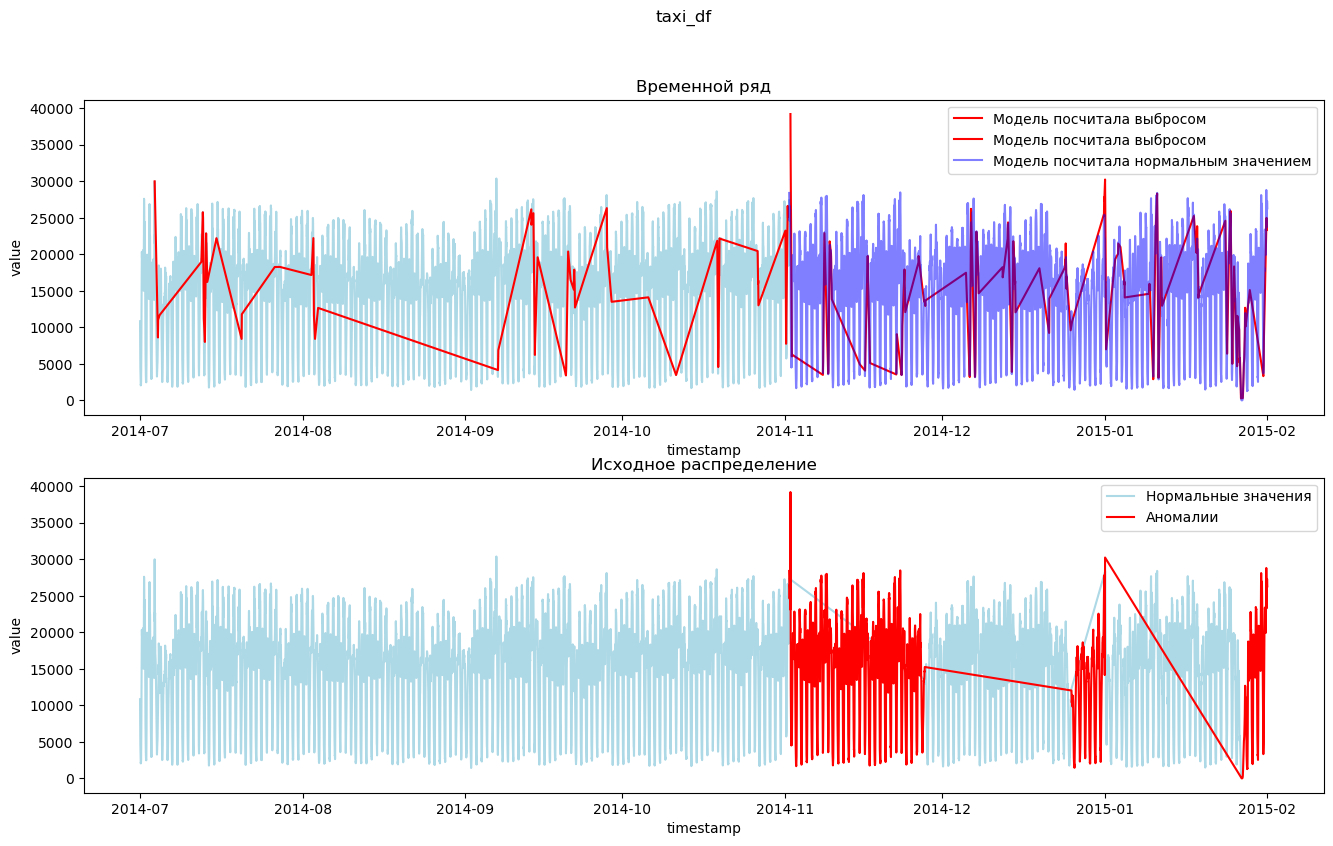

(               timestamp  value         trend      seasonal        resid  \
 0    2014-07-01 00:00:00  10844  16201.666197  -5040.953065  -316.713132   
 1    2014-07-01 00:30:00   8127  16189.919016  -8187.632349   124.713332   
 2    2014-07-01 01:00:00   6210  16178.228009 -10297.980408   329.752399   
 3    2014-07-01 01:30:00   4656  16166.594352 -11940.478909   429.884556   
 4    2014-07-01 02:00:00   3820  16155.018245 -12806.861213   471.842968   
 ...                  ...    ...           ...           ...          ...   
 5937 2014-11-01 16:30:00  18443  19022.887028  -1309.473137   729.586109   
 5938 2014-11-01 17:00:00  20865  19003.977398    565.132593  1295.890008   
 5939 2014-11-01 17:30:00  23719  18983.925649   2963.220241  1771.854110   
 5940 2014-11-01 18:00:00  25241  18962.823284   4257.394074  2020.782642   
 5941 2014-11-01 18:30:00  27383  18940.660306   6279.431941  2162.907753   
 
        predicted_m  error_forecast     score  context  threshold  predict

In [13]:
stl_score(df = taxi_df, threshold=2, name_df = 'taxi_df',
          get_plot=True, threshold_name= 'context_aware_threshold')

### Forecast-based SCORE

Forecast-based scoring — это подход к построению anomaly score, основанный на ошибке прогноза временного ряда. В отличие от residual-based подхода, где ожидаемое значение формируется через декомпозицию ряда на тренд, сезонность и остаток, в данном случае ожидаемое значение рассчитывается с помощью прогнозной модели. Основная идея состоит в том, что модель, обученная на нормальном поведении временного ряда, должна достаточно точно предсказывать будущие значения. Если фактическое значение существенно отличается от прогнозного, такое наблюдение получает высокий anomaly score.

Формально для каждого момента времени $t$ строится прогнозное значение $\hat{y}_t$, после чего рассчитывается ошибка прогноза:

$$
e_t = y_t - \hat{y}_t,
$$

где $y_t$ — фактическое значение ряда, а $\hat{y}_t$ — прогноз модели. В качестве anomaly score используется абсолютная величина ошибки прогноза или её стандартизированная форма:

$$
score_t = \left| \frac{e_t - \mu_{e, train}}{\sigma_{e, train}} \right|,
$$

где $\mu_{e, train}$ и $\sigma_{e, train}$ — среднее значение и стандартное отклонение ошибки прогноза, рассчитанные только на обучающей выборке. Это позволяет избежать утечки данных из тестовой выборки и делает оценку аномальности более корректной.

В рамках данной работы forecast-based scoring используется как один из способов получения численного показателя аномальности. На первом этапе модель прогноза формирует ожидаемое значение временного ряда, затем рассчитывается ошибка прогноза, после чего ошибка нормализуется по статистикам обучающей выборки. Чем выше значение `score`, тем сильнее наблюдение отклоняется от ожидаемого поведения ряда. Финальное решение о принадлежности точки к аномалиям принимается уже на следующем этапе — после выбора или автоматической настройки порогового значения.

In [14]:
def holt_winters(df:pd.DataFrame,
                 threshold:float = 2,
                 name_df:str = 'taxi_df',
                 get_plot:bool = True,
                 threshold_name:str = 'static_threshold',
                 window_period:int = 7,
                 quantile:float = 0.99,
                 context_col:str = 'hour',
                 k:float = 3):
    
    params = dict(taxi_df = 48, ambient_temp_df = 24, cpu_df = 12)

    period = params[name_df]
    window_size = period * window_period

    X_train, y_train, X_test, y_test = train_test_timeseries_split(df, train_size=0.8)

    X_train = X_train.copy()
    X_test = X_test.copy()
    
    model = ExponentialSmoothing(
        X_train["value"],
        trend="add",
        seasonal="add",
        seasonal_periods=period
    )
    
    fit = model.fit()

    X_train['predicted_m'] = fit.fittedvalues
    X_test['predicted_m'] = fit.forecast(X_test.shape[0])

    X_train['error_forecast'] = X_train['value'] - X_train['predicted_m']
    X_test['error_forecast'] = X_test['value'] - X_test['predicted_m']

    mu_error = X_train['error_forecast'].mean()
    std_error = X_train['error_forecast'].std()

    if std_error == 0:
        std_error = 1e-8

    X_train['score'] = np.abs((X_train['error_forecast'] - mu_error) / std_error)
    X_test['score'] = np.abs((X_test['error_forecast'] - mu_error) / std_error)

    X_train, X_test = apply_threshold(
        X_train,
        X_test,
        threshold_name=threshold_name,
        threshold=threshold,
        window=window_size,
        quantile=quantile,
        context_col=context_col,
        k=k
    )

    if get_plot:
        do_plot(df, X_train, X_test, name_df)
    
    return X_train, X_test, y_train, y_test

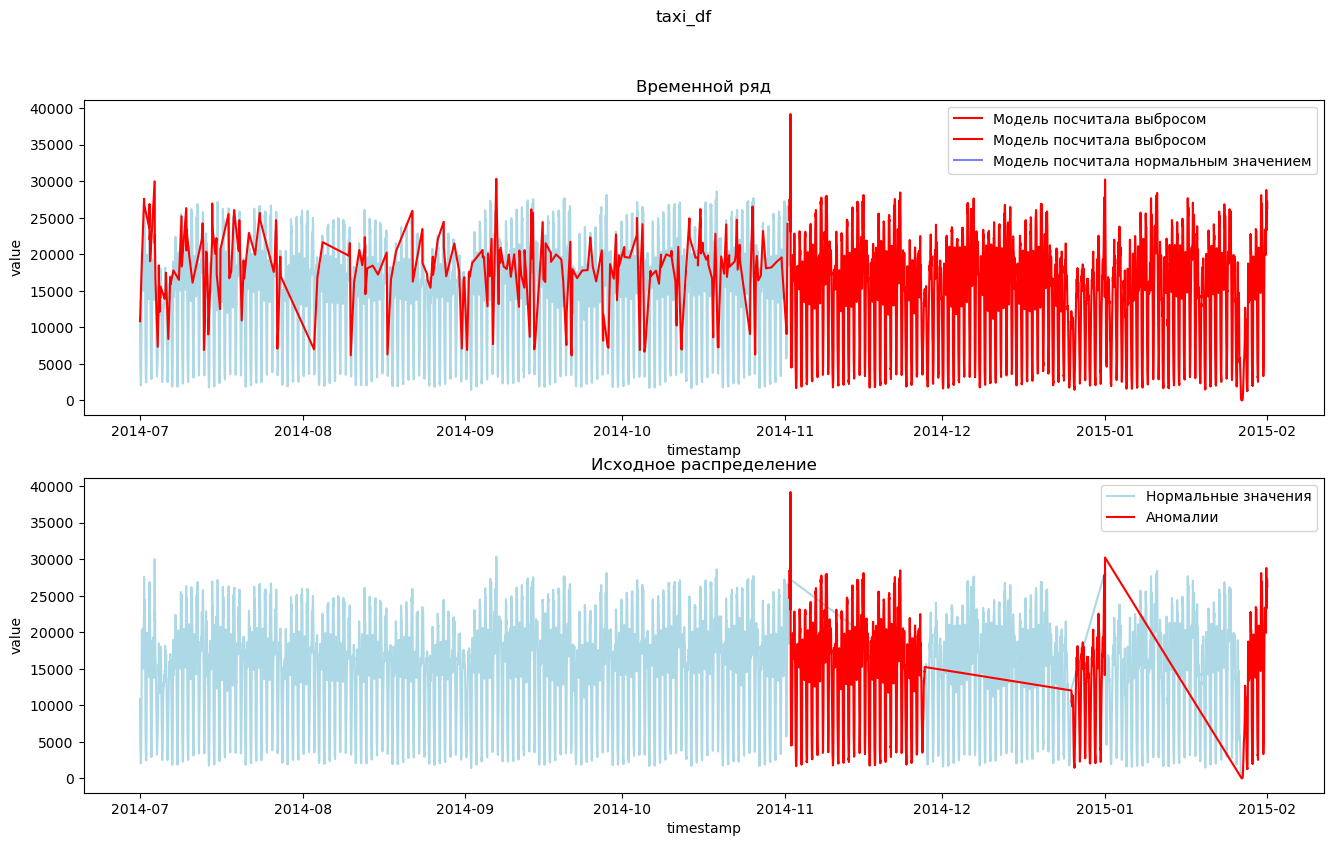

In [15]:
X_train, X_test, y_train, y_test = holt_winters(df = taxi_df, name_df = 'taxi_df',
                                                get_plot=True, threshold_name='static_threshold')

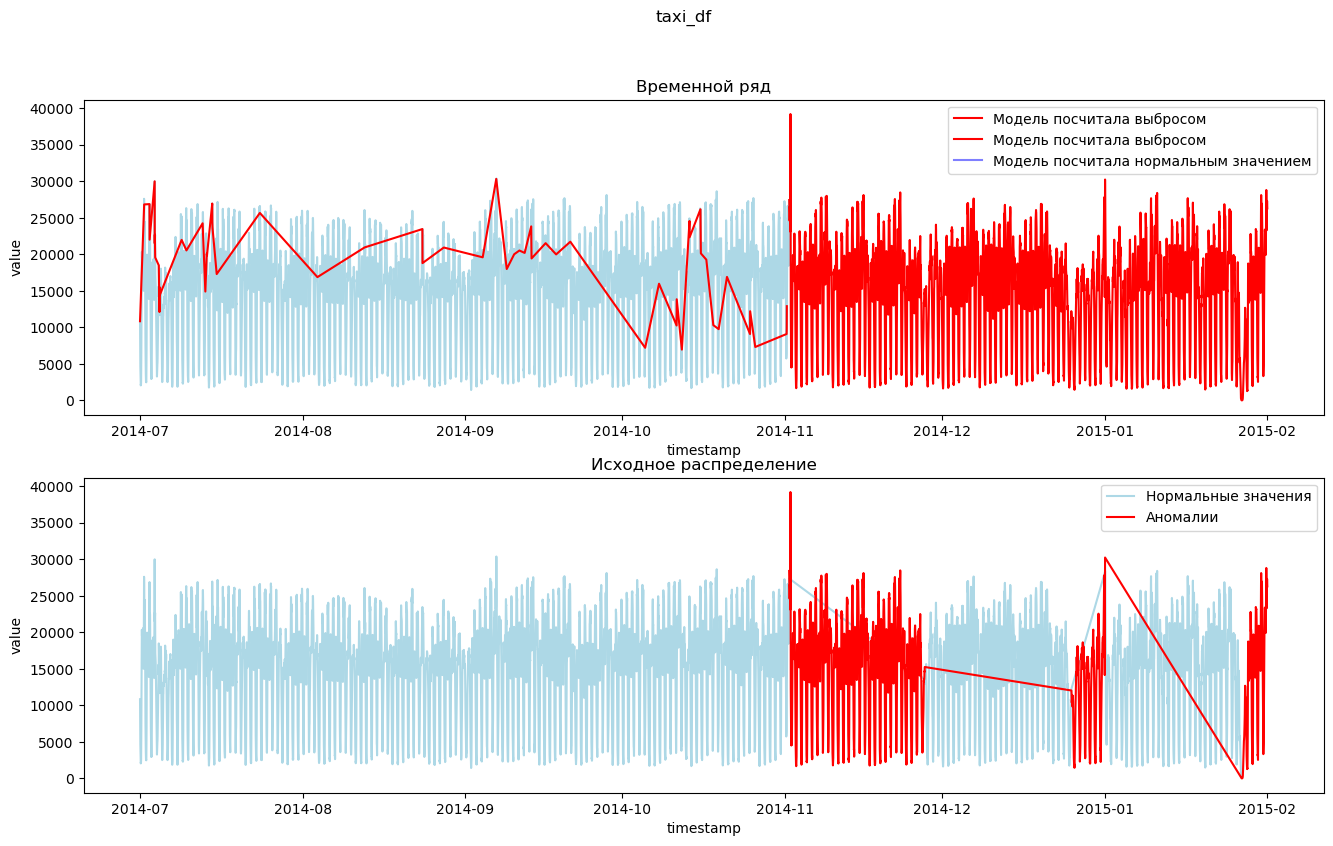

In [16]:
X_train, X_test, y_train, y_test = holt_winters(df = taxi_df, name_df = 'taxi_df',
                                                get_plot=True, threshold_name='prediction_interval_thresh')

Как видим, такой метод уже лучше определяет аномалии, но потом не может перестроиться на нормальные значения  Это может быть связано с тем, что прогноз делается сразу на весь тест, и при длинном окне выбросов модель не обновляется после начала теста

Вместо того чтобы переобучать Holt-Winters на каждой точке, будем переобучать его, например, каждые 
period точек.

In [156]:
def holt_winters_with_adaptation(df:pd.DataFrame,
                                 threshold:float = 3,
                                 name_df:str = 'taxi_df',
                                 get_plot:bool = True,
                                 threshold_name:str = 'static_threshold',
                                 window_period:int = 7,
                                 quantile:float = 0.99,
                                 context_col:str = 'hour',
                                 k:float = 3,
                                 adaptation_threshold:float = None):
    
    params = dict(taxi_df = 48, ambient_temp_df = 24, cpu_df = 12)
    refit_every = params[name_df]
    threshold = float(threshold)

    if adaptation_threshold is None:
        adaptation_threshold = threshold

    adaptation_threshold = float(adaptation_threshold)

    period = params[name_df]
    window_size = period * window_period

    X_train, y_train, X_test, y_test = train_test_timeseries_split(df, train_size=0.8)

    X_train = X_train.copy()
    X_test = X_test.copy()
    
    model = ExponentialSmoothing(
        X_train["value"],
        trend="add",
        seasonal="add",
        seasonal_periods=period
    )
    
    fit = model.fit()

    X_train['predicted_m'] = fit.fittedvalues

    X_train['error_forecast'] = X_train['value'] - X_train['predicted_m']

    mu_error = X_train['error_forecast'].mean()
    std_error = X_train['error_forecast'].std()

    if std_error == 0:
        std_error = 1e-8

    X_train['score'] = np.abs((X_train['error_forecast'] - mu_error) / std_error)

    history = list(X_train["value"].values)

    test_predictions = []
    test_forecast_errors = []
    test_scores = []
    test_adaptation_labels = []
    test_values = X_test['value'].values
    test_labels = []
    test_errors = []
    test_norm_errors = []
    
    for start in tqdm(range(0, len(test_values), refit_every)):
        end = start + refit_every
        block_values = test_values[start:end]

        # Берём последнее окно истории
        history_window = pd.Series(history[-window_size:])

        model = ExponentialSmoothing(
            history_window,
            trend="add",
            seasonal="add",
            seasonal_periods=period
        )

        fit = model.fit()

        # Прогнозируем сразу блок
        block_pred = fit.forecast(len(block_values)).values

        block_errors = block_values - block_pred
        block_norm_errors = (block_errors - mu_error) / std_error
        block_scores = np.abs(block_norm_errors)
        block_labels = (block_scores >= adaptation_threshold).astype(int)

        test_predictions.extend(block_pred)
        test_errors.extend(block_errors)
        test_norm_errors.extend(block_norm_errors)
        test_scores.extend(block_scores)
        test_labels.extend(block_labels)
               
        cleaned_block = np.where(
            block_labels == 0,
            block_values,
            block_pred
        )

        history.extend(cleaned_block.tolist())

    X_test["predicted_m"] = test_predictions
    X_test["error_forecast"] = test_errors
    X_test["normalized_error"] = test_norm_errors
    X_test["score"] = test_scores
    X_test["predicted"] = test_labels
    
    X_train, X_test = apply_threshold(
        X_train,
        X_test,
        threshold_name=threshold_name,
        threshold=threshold,
        window=window_size,
        quantile=quantile,
        context_col=context_col,
        k=k
    )

    if get_plot:
        do_plot(df, X_train, X_test, name_df)
    
    return X_train, X_test, y_train, y_test

То есть после аномалии модель не “учится” на выбросе, а подставляет ожидаемое значение. Благодаря этому после аномального периода Holt-Winters должен быстрее возвращаться к нормальному прогнозу.

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 92/92 [00:04<00:00, 18.85it/s]


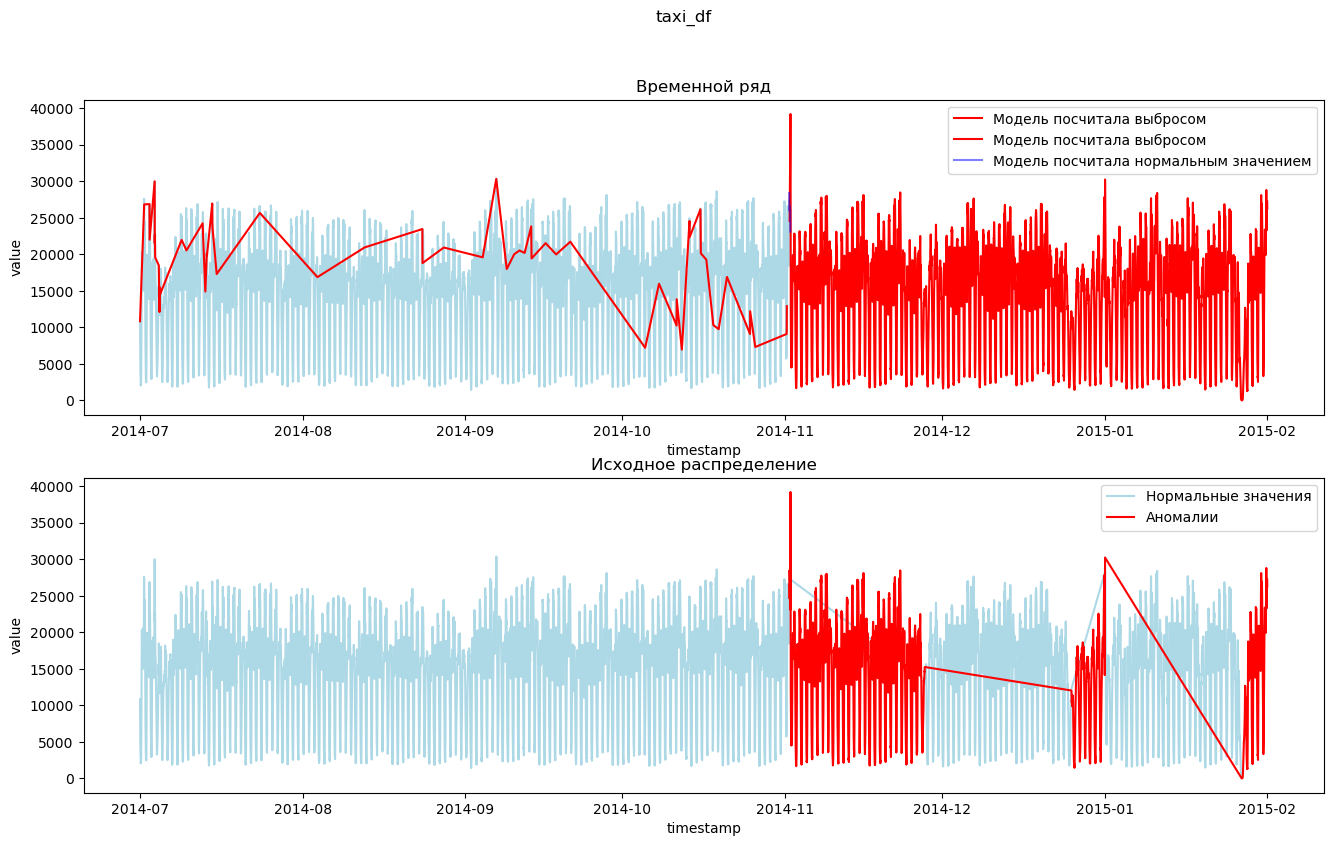

In [45]:
X_train, X_test, y_train, y_test = holt_winters_with_adaptation(df = taxi_df, 
                                                                name_df = 'taxi_df',
                                                                get_plot=True,
                                                                window_period=7,
                                                                threshold_name='prediction_interval_thresh')

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 148/148 [00:06<00:00, 22.03it/s]


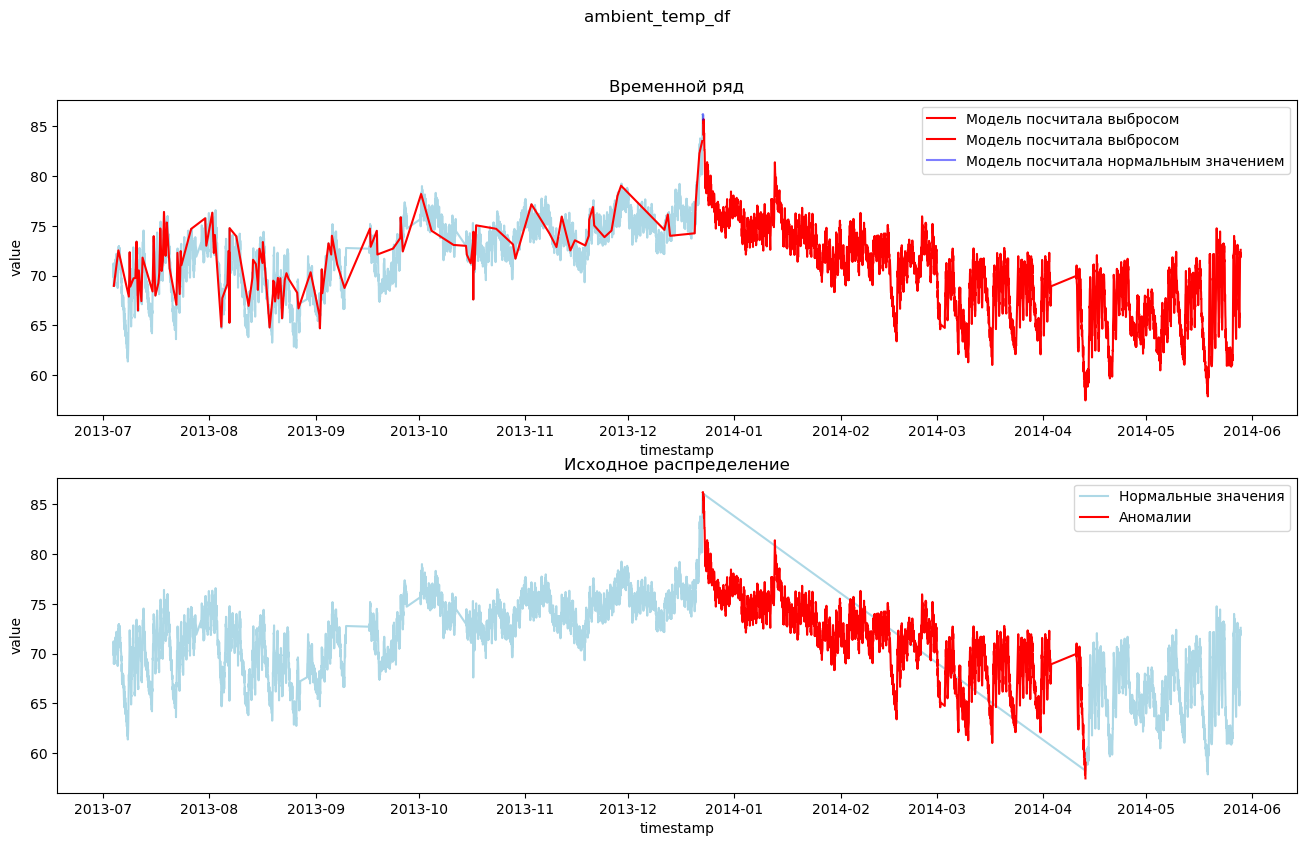

In [38]:
X_train, X_test, y_train, y_test = holt_winters_with_adaptation(df = ambient_temp_df, name_df = 'ambient_temp_df', get_plot=True)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 88/88 [00:03<00:00, 28.25it/s]


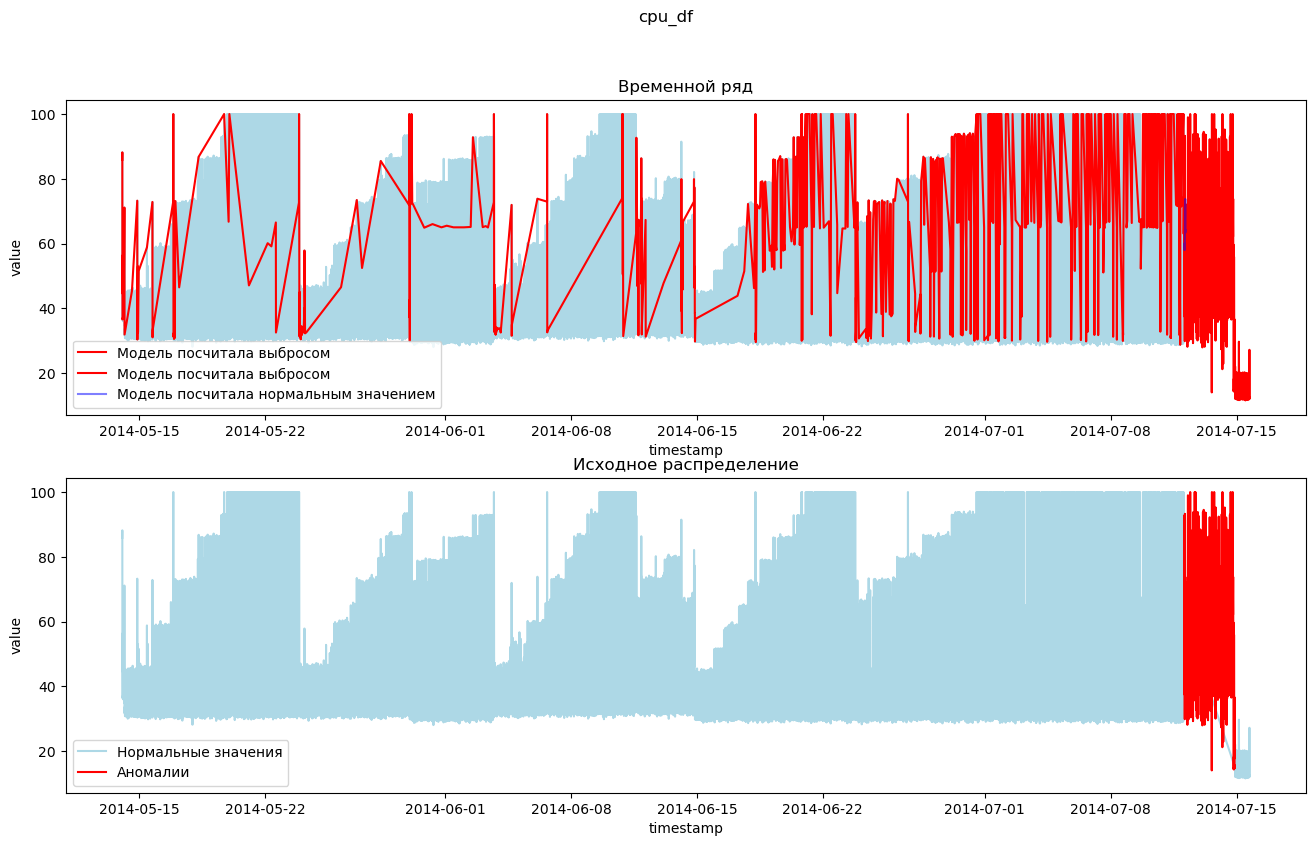

In [39]:
X_train, X_test, y_train, y_test = holt_winters_with_adaptation(df = cpu_df, name_df = 'cpu_df', get_plot=True)

In [133]:
def build_stl_seasonal_profile(train_values: pd.Series, period: int):
    #для каждой позиции в периоде создаем медиану сезонной компоненты
    stl = STL(train_values, period=period, robust=True)
    result = stl.fit()

    tmp = pd.DataFrame({
        "seasonal": result.seasonal.values,
        "pos_in_period": np.arange(len(train_values)) % period
    })

    seasonal_profile = tmp.groupby("pos_in_period")["seasonal"].median()

    return seasonal_profile

In [128]:
def make_catboost_ts_features(
    df: pd.DataFrame,
    period: int,
    seasonal_profile: pd.Series,
    value_col: str = "value"
):

    df = df.copy()

    df["pos_in_period"] = df["row_id"] % period
    df["stl_seasonal_profile"] = df["pos_in_period"].map(seasonal_profile)

    lags = sorted(set([
        1,
        2,
        3,
        period,
        period + 1,
        2 * period,
        3 * period
    ]))

    for lag in lags:
        df[f"lag_{lag}"] = df[value_col].shift(lag)

    shifted = df[value_col].shift(1)

    df[f"rolling_mean_{period}"] = shifted.rolling(period).mean()
    df[f"rolling_std_{period}"] = shifted.rolling(period).std()
    df[f"rolling_min_{period}"] = shifted.rolling(period).min()
    df[f"rolling_max_{period}"] = shifted.rolling(period).max()

    df[f"rolling_mean_{2 * period}"] = shifted.rolling(2 * period).mean()
    df[f"rolling_std_{2 * period}"] = shifted.rolling(2 * period).std()

    df["diff_1"] = df["lag_1"] - df["lag_2"]
    df["diff_period"] = df[f"lag_{period}"] - df[f"lag_{period + 1}"]

    possible_calendar_cols = [
        "hour",
        "day",
        "day_of_week",
        "weekday",
        "month",
        "is_weekend"
    ]

    feature_cols = [
        "pos_in_period",
        "stl_seasonal_profile",
        *[f"lag_{lag}" for lag in lags],
        f"rolling_mean_{period}",
        f"rolling_std_{period}",
        f"rolling_min_{period}",
        f"rolling_max_{period}",
        f"rolling_mean_{2 * period}",
        f"rolling_std_{2 * period}",
        "diff_1",
        "diff_period"
    ]

    for col in possible_calendar_cols:
        if col in df.columns:
            feature_cols.append(col)

    feature_cols = [col for col in feature_cols if col in df.columns]

    return df, feature_cols

In [284]:
def catboost_with_adaptation(
    df: pd.DataFrame,
    threshold: float = 3,
    name_df: str = "taxi_df",
    get_plot: bool = True,
    threshold_name: str = "static_threshold",
    window_period: int = 7,
    quantile: float = 0.99,
    context_col: str = "hour",
    k: float = 3,
    iterations: int = 300,
    depth: int = 4,
    learning_rate: float = 0.05,
    adaptation_threshold: float = None
):
    params = dict(
        taxi_df=48,
        ambient_temp_df=24,
        cpu_df=12
    )

    threshold = float(threshold)

    if adaptation_threshold is None:
        adaptation_threshold = threshold

    adaptation_threshold = float(adaptation_threshold)

    period = params[name_df]
    window_size = period * window_period

    # Будем переобучать модель один раз на сезонный период
    refit_every = period

    X_train, y_train, X_test, y_test = train_test_timeseries_split(
        df,
        train_size=0.8
    )

    X_train = X_train.copy()
    X_test = X_test.copy()

    # Нужен для позиции внутри сезона
    X_train["row_id"] = np.arange(len(X_train))
    X_test["row_id"] = np.arange(
        len(X_train),
        len(X_train) + len(X_test)
    )

    seasonal_profile = build_stl_seasonal_profile(
        X_train["value"],
        period=period
    )


    X_train, feature_cols = make_catboost_ts_features(
        X_train,
        period=period,
        seasonal_profile=seasonal_profile
    )

    train_model_df = X_train.dropna(
        subset=feature_cols + ["value"]
    ).copy()

    model = CatBoostRegressor(
        iterations=iterations,
        depth=depth,
        learning_rate=learning_rate,
        loss_function="RMSE",
        random_seed=42,
        verbose=False,
        allow_writing_files=False
    )
    #print("TRAIN MODEL DF SHAPE:", train_model_df.shape)
    #print("TRAIN VALUE NUNIQUE:", train_model_df["value"].nunique())
    #print("TRAIN VALUE MIN:", train_model_df["value"].min())
    #print("TRAIN VALUE MAX:", train_model_df["value"].max())
    #print("TRAIN VALUE STD:", train_model_df["value"].std())
    if can_fit_catboost(train_model_df, target_col="value"):
        model.fit(
            train_model_df[feature_cols],
            train_model_df["value"]
        )
    
        train_pred = model.predict(train_model_df[feature_cols])

    else:
        print("Warning: train target is constant. Using mean value as prediction.")
    
        train_pred = np.full(
            len(train_model_df),
            train_model_df["value"].mean()
        )

    train_pred = model.predict(train_model_df[feature_cols])

    train_model_df["predicted_m"] = train_pred
    train_model_df["error_forecast"] = (
        train_model_df["value"] - train_model_df["predicted_m"]
    )

    mu_error = train_model_df["error_forecast"].mean()
    std_error = train_model_df["error_forecast"].std()

    if pd.isna(std_error) or std_error == 0:
        std_error = 1e-8

    train_model_df["normalized_error"] = (
        (train_model_df["error_forecast"] - mu_error) / std_error
    )

    train_model_df["score"] = train_model_df["normalized_error"].abs()

    X_train["predicted_m"] = np.nan
    X_train["error_forecast"] = np.nan
    X_train["normalized_error"] = np.nan
    X_train["score"] = np.nan

    X_train.loc[train_model_df.index, "predicted_m"] = train_model_df["predicted_m"]
    X_train.loc[train_model_df.index, "error_forecast"] = train_model_df["error_forecast"]
    X_train.loc[train_model_df.index, "normalized_error"] = train_model_df["normalized_error"]
    X_train.loc[train_model_df.index, "score"] = train_model_df["score"]

    history_cols = ["row_id", "value"]

    possible_calendar_cols = [
        "hour",
        "day",
        "day_of_week",
        "weekday",
        "month",
        "is_weekend"
    ]

    for col in possible_calendar_cols:
        if col in X_train.columns:
            history_cols.append(col)

    history = X_train[history_cols].copy()


    test_predictions = []
    test_errors = []
    test_norm_errors = []
    test_scores = []
    test_adaptation_labels = []

    test_values = X_test["value"].values


    for start in tqdm(range(0, len(test_values), refit_every)):
        end = start + refit_every

        block = X_test.iloc[start:end].copy()
        block_values = block["value"].values

        # Берём последнее окно истории
        history_window = history.tail(window_size).copy()

        # Строим признаки на окне истории
        history_window, feature_cols = make_catboost_ts_features(
            history_window,
            period=period,
            seasonal_profile=seasonal_profile
        )

        history_model_df = history_window.dropna(
            subset=feature_cols + ["value"]
        ).copy()

        # Переобучаем CatBoost на последнем окне истории
        model = CatBoostRegressor(
            iterations=iterations,
            depth=depth,
            learning_rate=learning_rate,
            loss_function="RMSE",
            random_seed=42,
            verbose=False,
            allow_writing_files=False
        )

        fit_catboost = can_fit_catboost(
            history_model_df,
            target_col="value"
        )
        
        if fit_catboost:
            #print("HISTORY MODEL DF SHAPE:", history_model_df.shape)
            #print("HISTORY VALUE NUNIQUE:", history_model_df["value"].nunique())
            #print("HISTORY VALUE MIN:", history_model_df["value"].min())
            #print("HISTORY VALUE MAX:", history_model_df["value"].max())
            #print("HISTORY VALUE STD:", history_model_df["value"].std())
            model.fit(
                history_model_df[feature_cols],
                history_model_df["value"]
            )
        else:
            fallback_pred = history_model_df["value"].mean()


        for i in range(len(block)):
            current_row = block.iloc[[i]][history_cols].copy()

            actual_value = current_row["value"].iloc[0]


            current_row["value"] = np.nan

            temp_history = pd.concat(
                [history, current_row],
                ignore_index=True
            )

            temp_history, _ = make_catboost_ts_features(
                temp_history,
                period=period,
                seasonal_profile=seasonal_profile
            )

            current_features = temp_history.iloc[[-1]][feature_cols]

            if fit_catboost:
                y_pred = model.predict(current_features)[0]
            else:
                y_pred = fallback_pred

            error = actual_value - y_pred
            norm_error = (error - mu_error) / std_error
            score = abs(norm_error)

            adaptation_label = int(score >= adaptation_threshold)

            test_predictions.append(y_pred)
            test_errors.append(error)
            test_norm_errors.append(norm_error)
            test_scores.append(score)
            test_adaptation_labels.append(adaptation_label)

            # Если точка нормальная — добавляем факт.
            # Если аномальная — добавляем прогноз.
            clean_value = actual_value if adaptation_label == 0 else y_pred

            clean_row = block.iloc[[i]][history_cols].copy()
            clean_row["value"] = clean_value

            history = pd.concat(
                [history, clean_row],
                ignore_index=True
            )



    X_test["predicted_m"] = test_predictions
    X_test["error_forecast"] = test_errors
    X_test["normalized_error"] = test_norm_errors
    X_test["score"] = test_scores
    X_test["adaptation_label"] = test_adaptation_labels

 
    X_test["predicted"] = (
        X_test["score"] >= threshold
    ).astype(int)



    X_train, X_test = apply_threshold(
        X_train,
        X_test,
        threshold_name=threshold_name,
        threshold=threshold,
        window=window_size,
        quantile=quantile,
        context_col=context_col,
        k=k
    )

    if get_plot:
        do_plot(
            df,
            X_train,
            X_test,
            name_df
        )

    return X_train, X_test, y_train, y_test

ИТОГИ

In [177]:
def calc_metrics(X_train, X_test, y_test):
    y_true = y_test.values
    y_pred = X_test['predicted'].values

    train_fp_rate = X_train['predicted'].sum() / X_train.shape[0]

    normal_mask = y_true == 0

    if normal_mask.sum() == 0:
        test_fp_rate = 0
    else:
        test_fp_rate = ((y_pred == 1) & (y_true == 0)).sum() / normal_mask.sum()

    return {
        "train_fp_rate": train_fp_rate,
        "test_fp_rate": test_fp_rate,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0)
    }

In [184]:
threshold_methods = [
    'static_threshold',
    'rolling_quantile_threshold',
    'context_aware_threshold',
    'prediction_interval_thresh'
]

score_methods = {
    'stl_score': stl_score,
    'holt_winters': holt_winters,
    'holt_winters_with_adaptation': holt_winters_with_adaptation,
    'catboost_with_adaptation' : catboost_with_adaptation
}

dfs = [taxi_df, ambient_temp_df, cpu_df]
#dfs = [ ambient_temp_df, cpu_df]
names = ['taxi_df', 'ambient_temp_df', 'cpu_df']
#names = ['ambient_temp_df', 'cpu_df']

thresholds = [2, 2.5, 3]
quantiles = [0.68, 0.95, 0.99]
context_cols = ['dayofweek_hour', 'dayofweek', 'hour']
windows_periods = np.arange(7, 64, 7)
ks = [2, 2.5, 3]

results = pd.DataFrame(columns=[
    "dataset",
    "method",
    "threshold_type",
    "params",
    "train_fp_rate",
    "test_fp_rate",
    "precision",
    "recall",
    "f1_score",
    "status",
    "error"
])

In [185]:
def get_threshold_grid(threshold_method):
    if threshold_method == 'static_threshold':
        return [
            dict(threshold=threshold)
            for threshold in thresholds
        ]

    elif threshold_method == 'rolling_quantile_threshold':
        return [
            dict(quantile=quantile, window_period=window_period)
            for quantile in quantiles
            for window_period in windows_periods
        ]

    elif threshold_method == 'context_aware_threshold':
        return [
            dict(quantile=quantile, context_col=context_col)
            for quantile in quantiles
            for context_col in context_cols
        ]

    elif threshold_method == 'prediction_interval_thresh':
        return [
            dict(k=k)
            for k in ks
        ]

    else:
        return [dict()]

In [186]:
def can_fit_catboost(
    model_df: pd.DataFrame,
    target_col: str = "value",
    min_rows: int = 30,
    min_std: float = 1e-5
):
    if len(model_df) < min_rows:
        return False

    target = model_df[target_col].dropna()

    if target.nunique() <= 1:
        return False

    if target.std() < min_std:
        return False

    return True

In [187]:
for df, name_df in zip(dfs, names):
    print(name_df)
    for score_method_name, score_method in score_methods.items():
        print(score_method_name)
        for threshold_method in threshold_methods:
            for params in get_threshold_grid(threshold_method):
               
                X_train, X_test, y_train, y_test = score_method(
                    df=df.copy(),
                    name_df=name_df,
                    threshold_name=threshold_method,
                    get_plot=False,
                    **params
                )

                metrics = calc_metrics(X_train, X_test, y_test)

                results.loc[len(results)] = {
                    "dataset": name_df,
                    "method": score_method_name,
                    "threshold_type": threshold_method,
                    "params": str(params),
                    "train_fp_rate": metrics["train_fp_rate"],
                    "test_fp_rate": metrics["test_fp_rate"],
                    "precision": metrics["precision"],
                    "recall": metrics["recall"],
                    "f1_score": metrics["f1_score"],
                    "status": "ok",
                    "error": ""
                }

                #print(name_df, score_method_name, threshold_method, f'ОТРАБОТАНО')
                #print('-' * 50)

taxi_df
stl_score
holt_winters
holt_winters_with_adaptation


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 92/92 [00:04<00:00, 18.72it/s]


catboost_with_adaptation


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 92/92 [00:36<00:00,  2.55it/s]


ambient_temp_df
stl_score
holt_winters
holt_winters_with_adaptation


...

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 148/148 [00:29<00:00,  4.96it/s]


cpu_df
stl_score
holt_winters
holt_winters_with_adaptation


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 88/88 [00:03<00:00, 28.62it/s]


catboost_with_adaptation


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 88/88 [00:31<00:00,  2.77it/s]


In [239]:
results.sort_values(by = 'f1_score')

,dataset,method,threshold_type,params,train_fp_rate,test_fp_rate,precision,recall,f1_score,status,error,train_test_fp,f1_add_train_test_fp,f05
22,taxi_df,stl_score,rolling_quantile_threshold,"{'quantile': 0.99, 'window_period': 14}",0.012959,0.010823,0.450980,0.012842,0.024973,ok,,0.023782,0.001191,0.057644
23,taxi_df,stl_score,rolling_quantile_threshold,"{'quantile': 0.99, 'window_period': 21}",0.013632,0.010050,0.480000,0.013400,0.026073,ok,,0.023682,0.002391,0.060271
21,taxi_df,stl_score,rolling_quantile_threshold,"{'quantile': 0.99, 'window_period': 7}",0.014642,0.015848,0.378788,0.013959,0.026925,ok,,0.030490,-0.003565,0.060827
24,taxi_df,stl_score,rolling_quantile_threshold,"{'quantile': 0.99, 'window_period': 28}",0.011444,0.009664,0.509804,0.014517,0.028230,ok,,0.021108,0.007123,0.065163
25,taxi_df,stl_score,rolling_quantile_threshold,"{'quantile': 0.99, 'window_period': 35}",0.011612,0.010050,0.518519,0.015634,0.030352,ok,,0.021663,0.008690,0.069756
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
409,cpu_df,holt_winters,context_aware_threshold,"{'quantile': 0.68, 'context_col': 'dayofweek'}",0.320021,1.000000,0.775549,0.998770,0.873118,ok,,1.320021,-0.446903,0.811838
408,cpu_df,holt_winters,context_aware_threshold,"{'quantile': 0.68, 'context_col': 'dayofweek_h...",0.323433,1.000000,0.775549,0.998770,0.873118,ok,,1.323433,-0.450314,0.811838
386,cpu_df,holt_winters,rolling_quantile_threshold,"{'quantile': 0.68, 'window_period': 42}",0.322550,1.000000,0.775549,0.998770,0.873118,ok,,1.322550,-0.449432,0.811838
387,cpu_df,holt_winters,rolling_quantile_threshold,"{'quantile': 0.68, 'window_period': 49}",0.324491,1.000000,0.775549,0.998770,0.873118,ok,,1.324491,-0.451373,0.811838


Использование только F1-score оказалось недостаточным для оценки качества моделей, поскольку при высокой концентрации аномальных значений в тестовой выборке модель может достигать высокого значения F1 за счёт чрезмерно широкого выделения аномальной области. Поэтому дополнительно учитывалась доля ложноположительных срабатываний на тестовой выборке, а выбор лучшей модели выполнялся не только по F1-score, но и с учётом ограничения на FPR. Такую ситуацию лучше всего отразит f0.5 которая сильнее штрафует модель за ложноположительные срабатывания

In [286]:
results['f05'] = (1 + 0.5**2) * results['precision'] * results['recall'] \
                    / (0.5**2 * results['precision'] + results['recall'])

research_columns = ['dataset', 'method', 'threshold_type', 'params', 'train_fp_rate','precision', 'recall', 'f1_score', 'f05']
research_df = pd.DataFrame(columns=research_columns)

In [287]:
research_df.loc[0] = results.query("dataset == 'taxi_df'")\
        .sort_values(by='f05', ascending=False).iloc[0].loc[research_columns]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 92/92 [00:25<00:00,  3.56it/s]


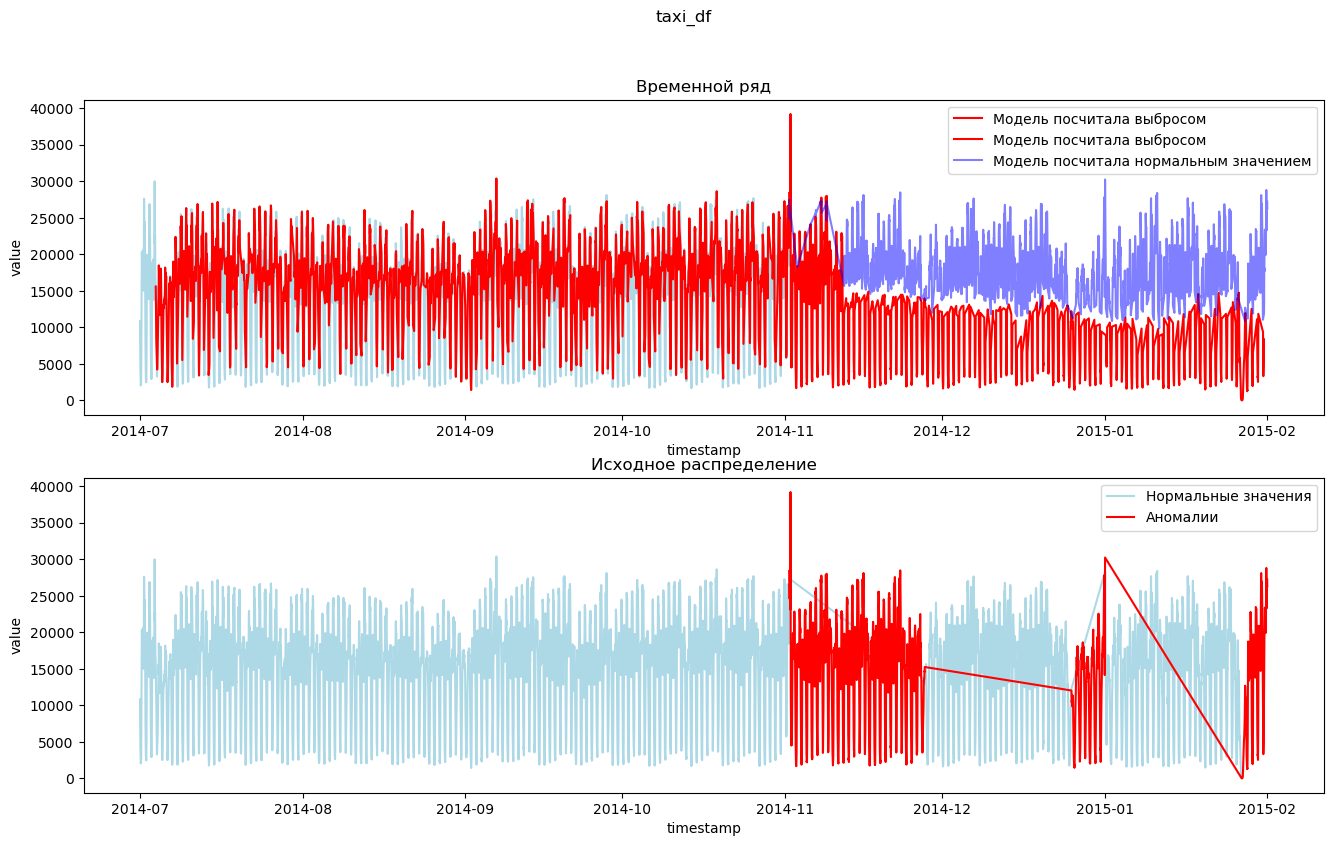

In [288]:
_,_,_,_ = catboost_with_adaptation(taxi_df, name_df = 'taxi_df', threshold_name = 'rolling_quantile_threshold',
                        quantile=0.68, window_period = 21)

In [289]:
research_df.loc[1] = results.query("dataset == 'ambient_temp_df'")\
        .sort_values(by='f05', ascending=False).iloc[0].loc[research_columns]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 148/148 [00:32<00:00,  4.53it/s]


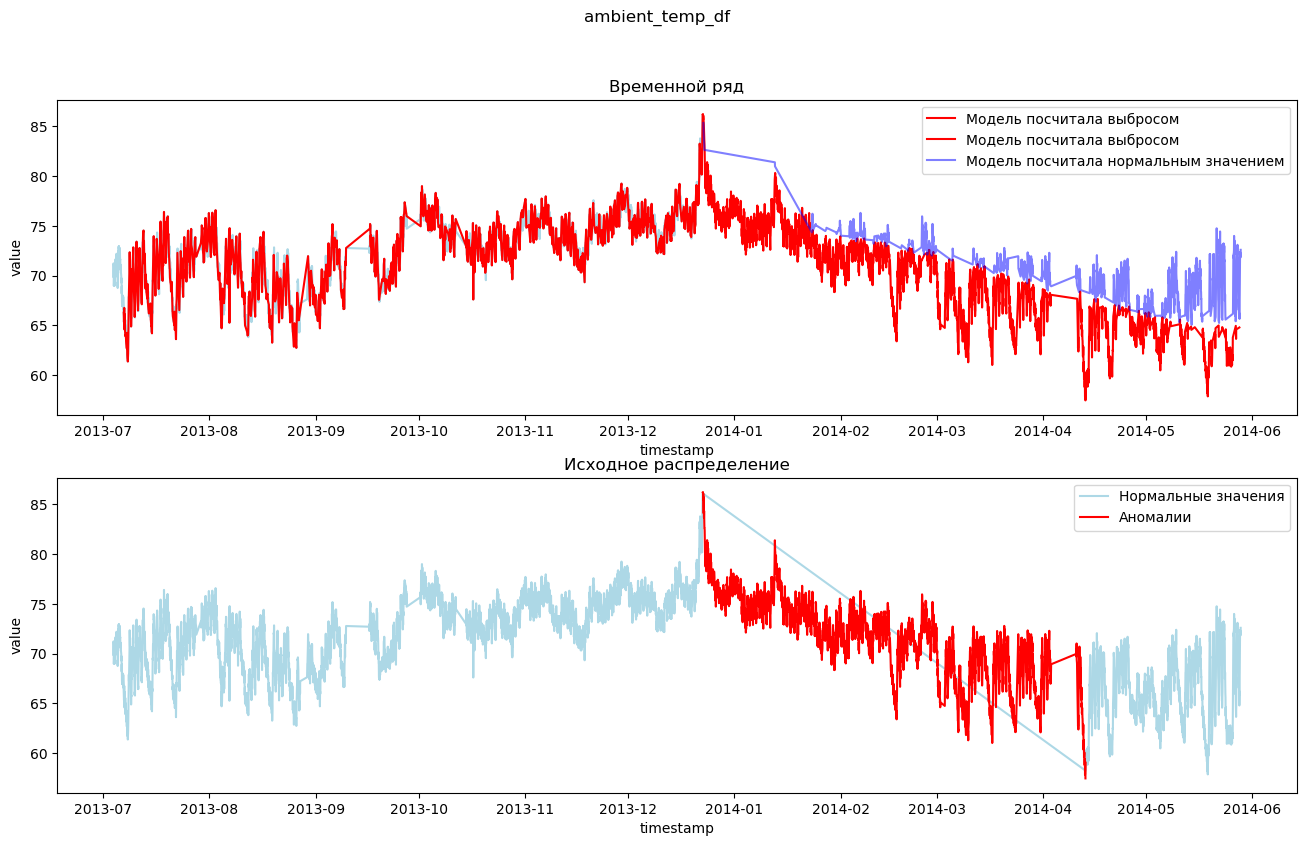

In [290]:
_,_,_,_ = catboost_with_adaptation(ambient_temp_df, name_df = 'ambient_temp_df', threshold_name = 'rolling_quantile_threshold',
                        quantile=.68, window_period = 63)

In [291]:
research_df.loc[2] = results.query("dataset == 'cpu_df'")\
        .sort_values(by='f05', ascending=False).iloc[0].loc[research_columns]

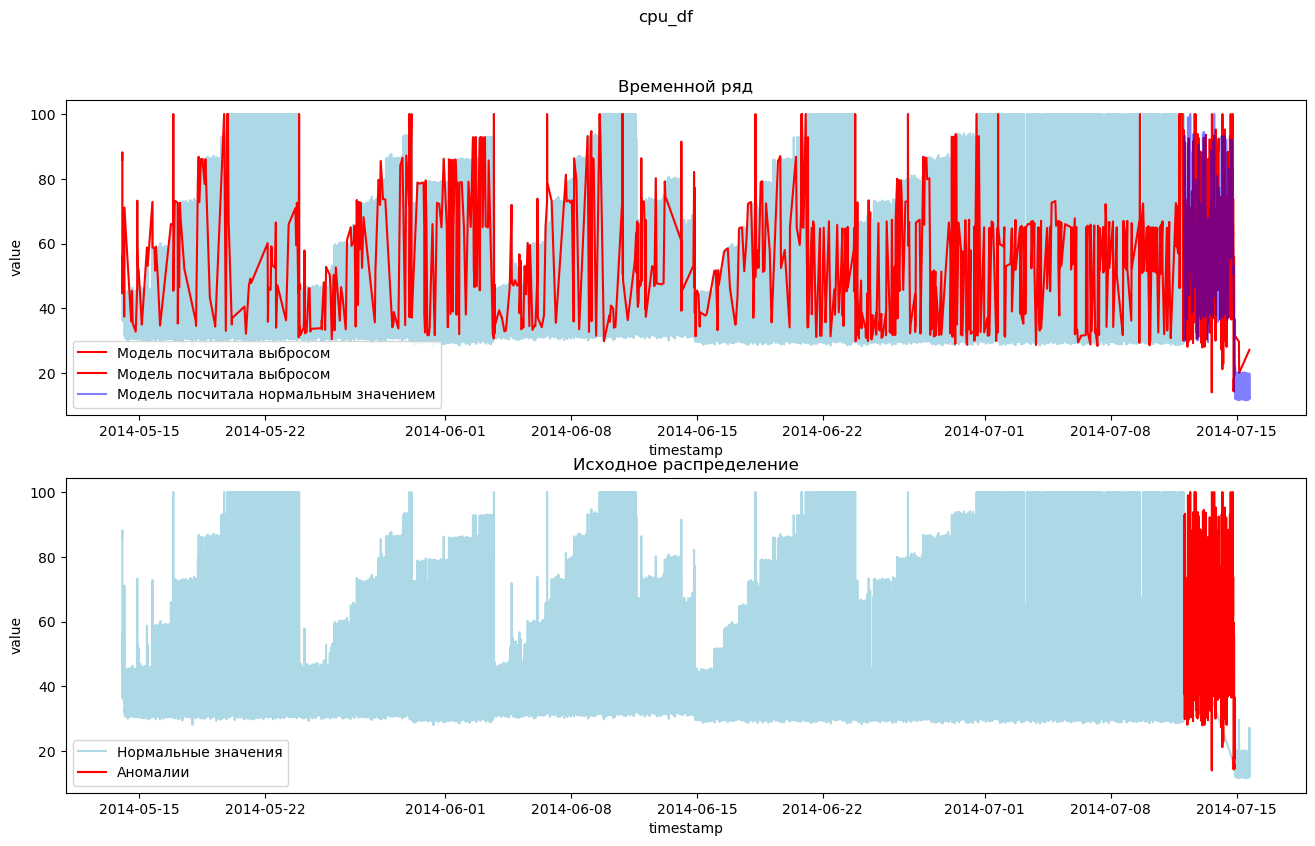

In [292]:
_, _, _, _ = stl_score(cpu_df, name_df = 'cpu_df', threshold_name = 'context_aware_threshold',
                        quantile=.95, context_col = 'dayofweek')

In [293]:
research_df['baseline'] = False

В ходе экспериментов было установлено, что увеличение количества сезонных периодов, используемых для адаптивного переобучения модели Holt-Winters, положительно влияет на качество обнаружения аномалий. Наилучшие значения метрик были получены при использовании окна, включающего более 45 сезонных циклов. Это может свидетельствовать о том, что исследуемый временной ряд обладает устойчивой повторяющейся сезонной структурой, для корректной оценки которой требуется достаточно длинная историческая выборка.

In [297]:
baseline = pd.read_csv('baseline.csv')


In [301]:
research_df = pd.concat([baseline, research_df])

In [302]:
research_df = research_df.fillna(True)

In [306]:
research_df = research_df.reset_index(drop=True)

In [310]:
research_df.sort_values(by = 'f05', ascending=False)

,dataset,method,threshold_type,params,train_fp_rate,precision,recall,f1_score,f05,baseline
11,cpu_df,stl_score,context_aware_threshold,"{'quantile': 0.68, 'context_col': 'dayofweek_h...",0.323433,0.980551,0.744157,0.846154,0.921975,False
2,cpu_df,static,static_quantile,True,0.400200,0.862239,0.748932,0.800000,0.836915,True
10,ambient_temp_df,catboost_with_adaptation,rolling_quantile_threshold,"{'quantile': 0.68, 'window_period': 63}",0.306638,0.796917,0.840650,0.818200,0.805296,False
9,taxi_df,catboost_with_adaptation,rolling_quantile_threshold,"{'quantile': 0.99, 'window_period': 21}",0.011444,0.912791,0.262982,0.408322,0.610895,False
1,ambient_temp_df,static,static_quantile,True,0.400400,0.430488,0.554450,0.480000,0.450638,True
0,taxi_df,static,static_quantile,True,0.400200,0.414294,0.408590,0.410000,0.413140,True
8,cpu_df,stl_zscore,stl_zscore,threshold = 2.0,0.022800,0.322263,0.996198,0.490000,0.372688,True
5,cpu_df,zscore_method,z_score,threshold = 2.0,0.064200,0.168512,1.000000,0.290000,0.202125,True
4,ambient_temp_df,zscore_method,z_score,threshold = 2.0,0.043800,0.114634,0.373016,0.180000,0.133069,True
6,taxi_df,stl_zscore,stl_zscore,threshold = 2.0,0.082600,0.094361,0.419355,0.150000,0.111669,True


Среди baseline-подходов (`static`, `z_score`, `stl_zscore`) наилучшие результаты по метрике \(F_{0.5}\) на всех трёх датасетах показал метод со статическим квантильным порогом. Поэтому дальнейшее сравнение целесообразно проводить именно с ним как с сильнейшим baseline.

Для датасета `cpu_df` лучший итоговый результат показал метод `stl_score` с `context_aware_threshold`: \(precision = 0.981\), \(recall = 0.744\), \(F1 = 0.846\), \(F_{0.5} = 0.922\). Лучший baseline (`static`) на этом же датасете дал \(precision = 0.862\), \(recall = 0.749\), \(F1 = 0.800\), \(F_{0.5} = 0.837\). Таким образом, предложенный подход улучшает \(F_{0.5}\) на 0.085 и заметно повышает precision, практически не теряя recall. Это указывает на то, что для ряда `cpu_df` учёт контекста после STL-разложения позволяет сократить количество ложных срабатываний и при этом сохранить высокую полноту.

Для датасета `ambient_temp_df` наилучшим оказался метод `catboost_with_adaptation` с `rolling_quantile_threshold`: \(precision = 0.797\), \(recall = 0.841\), \(F1 = 0.818\), \(F_{0.5} = 0.805\). Лучший baseline (`static`) показал значительно более слабые результаты: \(precision = 0.430\), \(recall = 0.554\), \(F1 = 0.480\), \(F_{0.5} = 0.451\). Абсолютный прирост по \(F_{0.5}\) составил 0.355, при этом выросли и precision, и recall. Следовательно, для этого временного ряда адаптивная модель даёт не только более точную, но и более полную детекцию аномалий, существенно превосходя простые пороговые схемы.

Для датасета `taxi_df` лучший результат среди исследуемых методов также показал `catboost_with_adaptation`: \(precision = 0.913\), \(recall = 0.263\), \(F1 = 0.408\), \(F_{0.5} = 0.611\). Лучший baseline (`static`) дал \(precision = 0.414\), \(recall = 0.409\), \(F1 = 0.410\), \(F_{0.5} = 0.413\). Здесь прирост по \(F_{0.5}\) составил 0.198 за счёт резкого повышения precision, хотя recall снизился. Это означает, что на ряде `taxi_df` адаптивный метод работает более консервативно: он обнаруживает меньшую долю аномалий, но делает это существенно точнее и с меньшим количеством ложноположительных срабатываний. В условиях, где приоритетом является снижение числа ложных тревог, такой результат можно считать предпочтительным.

В целом проведённое исследование показало, что простые baseline-подходы могут оставаться конкурентоспособными на относительно более простых рядах, как в случае `cpu_df`, однако в большинстве случаев адаптивные методы и контекстно-зависимые пороги оказываются эффективнее. Наибольший выигрыш наблюдается там, где временной ряд обладает более сложной структурой сезонности и изменчивости, как для `ambient_temp_df`. Для `taxi_df` улучшение достигается прежде всего за счёт precision, что согласуется с выбором метрики \(F_{0.5}\), ориентированной на минимизацию ложноположительных срабатываний. 